In [6]:
import HeST as H
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import re

from qetpy.utils import fft, ifft, fftfreq, rfftfreq


## Plotting basic Quasiparticle curves
- Energy vs momentum
- Velocity vs momentum
- Critical Angle vs momentum

Text(0, 0.5, 'Critical Angle (degrees)')

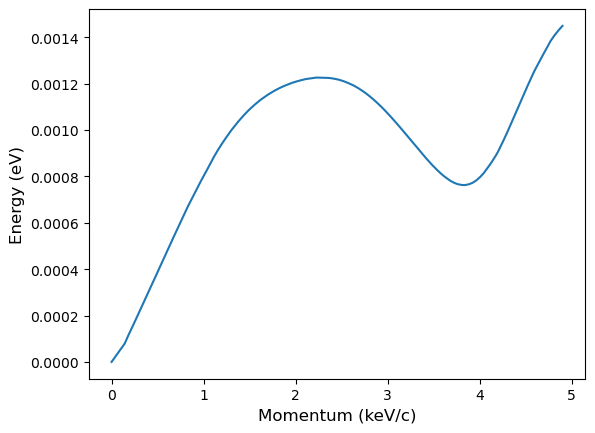

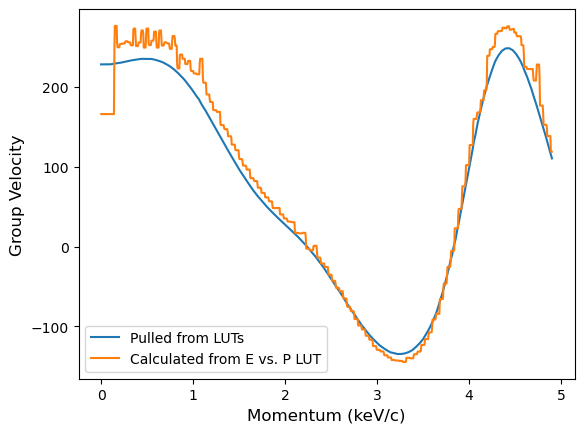

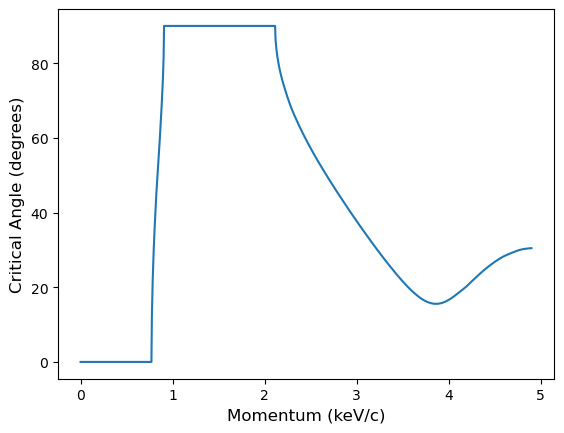

In [7]:
ks = np.linspace(0,4.9,1000)
Es = H.QP_dispersion(ks)
vs = H.QP_velocity(ks)

fig, ax = plt.subplots()
ax.plot(ks, Es)
ax.set_xlabel('Momentum (keV/c)', fontsize = 12)
ax.set_ylabel('Energy (eV)', fontsize = 12)


vs2 = 1.602e-19/5.344286e-25 * np.diff(Es) / np.diff(ks)
ks2 = (ks[1:] + ks[:-1])/2


fig, ax = plt.subplots()
ax.plot(ks, vs, label = 'Pulled from LUTs')
ax.plot(ks2, vs2, label = 'Calculated from E vs. P LUT')
ax.set_xlabel('Momentum (keV/c)', fontsize = 12)
ax.set_ylabel('Group Velocity', fontsize = 12)
ax.legend()




mHe = 6.64216e-27 #kg

vB = 9.9334947e-23 #J

# thetas = 180 / np.pi *  np.arcsin(np.sqrt(2* mHe * (Es*1.602e-19 - vB))/(ks *5.344286e-25))

fig, ax = plt.subplots()

ax.plot(ks, H.critical_angle(Es, ks) * 180 / np.pi)
ax.set_xlabel('Momentum (keV/c)', fontsize = 12)
ax.set_ylabel('Critical Angle (degrees)', fontsize = 12)

## Yields Plots
- Assumed fractional yields for ER/NR 
- Total QP yields vs recoil energy (assumes T = 2 K thermal distribution)

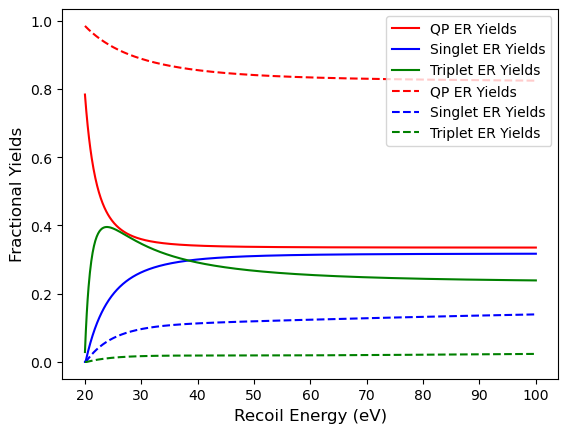

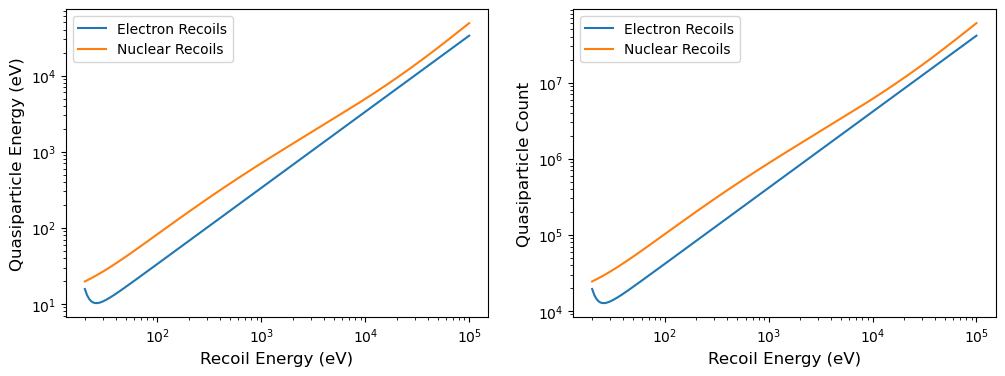

In [8]:
E_data = np.linspace(20,100, 1000)
QP_ER_data = H.ER_QP_eFraction(E_data)
singlet_ER_data = H.ER_singlet_eFraction(E_data)

triplet_ER_data = H.ER_triplet_eFraction(E_data)

QP_NR_data = H.NR_QP_eFraction(E_data)
singlet_NR_data = H.NR_singlet_eFraction(E_data)
triplet_NR_data = H.NR_triplet_eFraction(E_data)

fig, ax = plt.subplots()

ax.plot(E_data, QP_ER_data, color = 'r', label = 'QP ER Yields')
ax.plot(E_data, singlet_ER_data, color = 'b', label = 'Singlet ER Yields')
ax.plot(E_data, triplet_ER_data, color = 'g', label = 'Triplet ER Yields')

ax.plot(E_data, QP_NR_data, color = 'r', ls = '--', label = 'QP ER Yields')
ax.plot(E_data, singlet_NR_data, color = 'b', ls = '--', label = 'Singlet ER Yields')
ax.plot(E_data, triplet_NR_data, color = 'g', ls = '--', label = 'Triplet ER Yields')

ax.set_xlabel('Recoil Energy (eV)', fontsize = 12 )
ax.set_ylabel('Fractional Yields', fontsize = 12 )

ax.legend()

E_data = np.linspace(20,100000, 100000)

fig, ax = plt.subplots(ncols = 2, figsize= (12,4))

ax[0].plot(E_data, H.ER_QP_eFraction(E_data)*E_data, label = 'Electron Recoils')
ax[0].plot(E_data, H.NR_QP_eFraction(E_data)*E_data, label = 'Nuclear Recoils')

ax[0].set_xlabel('Recoil Energy (eV)', fontsize = 12)
ax[0].set_ylabel('Quasiparticle Energy (eV)', fontsize = 12)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].legend()



ax[1].plot(E_data, H.est_QPcount(H.ER_QP_eFraction(E_data)*E_data, T= 2), label = 'Electron Recoils')
ax[1].plot(E_data, H.est_QPcount(H.NR_QP_eFraction(E_data)*E_data, T= 2), label = 'Nuclear Recoils')
ax[1].set_xlabel('Recoil Energy (eV)', fontsize = 12)
ax[1].set_ylabel('Quasiparticle Count', fontsize = 12)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].legend()

## Sampling Quasiparticle Momenta

We assume that, during the instant after a point-like energy deposition in the helium, the quasiparticles produced are well-confined enough to be in thermal equilibrium with each other due to scattering. Over time, the cloud of quasiparticles expands, and at some point the quasiparticles "freeze out" of thermal equilibrium and free stream. The operatnt question is: what is the temperature of the distribution of the distribution at the time of free-streaming? We tacitly assume 2 K based on You et. al., but here you can get a feel for what the actual distribution of momenta looks like and how it's sensitive to this temperature.

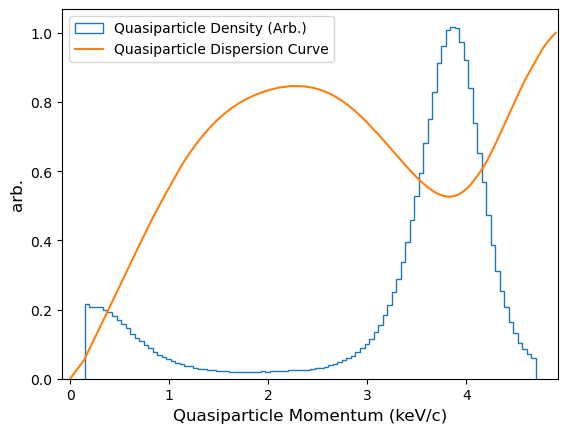

In [10]:
fig, ax  = plt.subplots()
T = 2
moms = H.Random_QPmomentum(1000000,T = T)
ax.hist(moms, bins = 100, histtype = 'step',
        density = True, label = 'Quasiparticle Density (Arb.)')

ax.set_xlim()



ks = np.linspace(0,4.9,1000)
Es = H.QP_dispersion(ks)

ax.plot(ks, Es/max(Es), label = 'Quasiparticle Dispersion Curve')
ax.set_xlabel('Quasiparticle Momentum (keV/c)', fontsize = 12)
ax.set_ylabel('arb.', fontsize = 12)

ax.legend()

